<a href="https://colab.research.google.com/github/HamzaEric/Heart_Diagnosis_MLP/blob/main/Notebooks/Pytorch_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/heart.csv")
print(df.shape)
print(df.head())

(303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [4]:
df = df.dropna()
print("Remaining rows:", df.shape[0])

Remaining rows: 297


In [5]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df['target'].value_counts()

,count
target,
0,160
1,137


In [6]:
X = df.drop(columns=['num', 'target'])
y = df['target']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 237
Test size: 60


In [9]:
# Define model
model = nn.Sequential(
    nn.Linear(13, 16),   # Input layer → Hidden layer (13 → 16)
    nn.ReLU(),           # Activation
    nn.Linear(16, 1),    # Hidden → Output layer (16 → 1)
    nn.Sigmoid()         # Output activation for binary classification
)

# Show architecture
print(model)

Sequential(
  (0): Linear(in_features=13, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)


In [10]:
sum(p.numel() for p in model.parameters())

241

In [11]:
custom_model = nn.Sequential(
    nn.Linear(13, 32),
    nn.LeakyReLU(),

    nn.Dropout(p=0.3),  # Randomly disables 30% of the 32 neurons during training

    nn.Linear(32, 16),
    nn.Sigmoid(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)
# Print model architecture
print(custom_model)

Sequential(
  (0): Linear(in_features=13, out_features=32, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): Sigmoid()
  (5): Linear(in_features=16, out_features=1, bias=True)
  (6): Sigmoid()
)


In [12]:
loss_fn = nn.BCELoss()

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [15]:
num_epochs = 500
train_losses = []

for epoch in range(num_epochs):
    custom_model.train()

    # Forward pass
    outputs = custom_model(X_train)
    loss = loss_fn(outputs, y_train)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Save loss
    train_losses.append(loss.item())

    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [10/500], Loss: 0.7021
Epoch [20/500], Loss: 0.7029
Epoch [30/500], Loss: 0.7024
Epoch [40/500], Loss: 0.7023
Epoch [50/500], Loss: 0.7038
Epoch [60/500], Loss: 0.7019
Epoch [70/500], Loss: 0.7035
Epoch [80/500], Loss: 0.7031
Epoch [90/500], Loss: 0.7034
Epoch [100/500], Loss: 0.7026
Epoch [110/500], Loss: 0.7029
Epoch [120/500], Loss: 0.7031
Epoch [130/500], Loss: 0.7011
Epoch [140/500], Loss: 0.7026
Epoch [150/500], Loss: 0.7024
Epoch [160/500], Loss: 0.7020
Epoch [170/500], Loss: 0.7021
Epoch [180/500], Loss: 0.7021
Epoch [190/500], Loss: 0.7036
Epoch [200/500], Loss: 0.7033
Epoch [210/500], Loss: 0.7032
Epoch [220/500], Loss: 0.7025
Epoch [230/500], Loss: 0.7034
Epoch [240/500], Loss: 0.7032
Epoch [250/500], Loss: 0.7034
Epoch [260/500], Loss: 0.7028
Epoch [270/500], Loss: 0.7020
Epoch [280/500], Loss: 0.7023
Epoch [290/500], Loss: 0.7020
Epoch [300/500], Loss: 0.7021
Epoch [310/500], Loss: 0.7037
Epoch [320/500], Loss: 0.7021
Epoch [330/500], Loss: 0.7026
Epoch [340/500], Lo

In [16]:
num_epochs = 500
train_losses = []
test_losses = []


for epoch in range(num_epochs):
    custom_model.train()

    outputs = custom_model(X_train)
    loss = loss_fn(outputs, y_train.view(-1, 1).float())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    custom_model.eval()

    with torch.no_grad():
        test_outputs = custom_model(X_test)

        test_loss = loss_fn(test_outputs, y_test.view(-1, 1).float())
        test_losses.append(test_loss.item())

    # Print both losses every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}")

Epoch [10/500], Train Loss: 0.7022, Test Loss: 0.7136
Epoch [20/500], Train Loss: 0.7024, Test Loss: 0.7136
Epoch [30/500], Train Loss: 0.7019, Test Loss: 0.7136
Epoch [40/500], Train Loss: 0.7025, Test Loss: 0.7136
Epoch [50/500], Train Loss: 0.7020, Test Loss: 0.7136
Epoch [60/500], Train Loss: 0.7010, Test Loss: 0.7136
Epoch [70/500], Train Loss: 0.7020, Test Loss: 0.7136
Epoch [80/500], Train Loss: 0.7024, Test Loss: 0.7136
Epoch [90/500], Train Loss: 0.7027, Test Loss: 0.7136
Epoch [100/500], Train Loss: 0.7036, Test Loss: 0.7136
Epoch [110/500], Train Loss: 0.7021, Test Loss: 0.7136
Epoch [120/500], Train Loss: 0.7034, Test Loss: 0.7136
Epoch [130/500], Train Loss: 0.7027, Test Loss: 0.7136
Epoch [140/500], Train Loss: 0.7034, Test Loss: 0.7136
Epoch [150/500], Train Loss: 0.7027, Test Loss: 0.7136
Epoch [160/500], Train Loss: 0.7032, Test Loss: 0.7136
Epoch [170/500], Train Loss: 0.7018, Test Loss: 0.7136
Epoch [180/500], Train Loss: 0.7027, Test Loss: 0.7136
Epoch [190/500], Tr

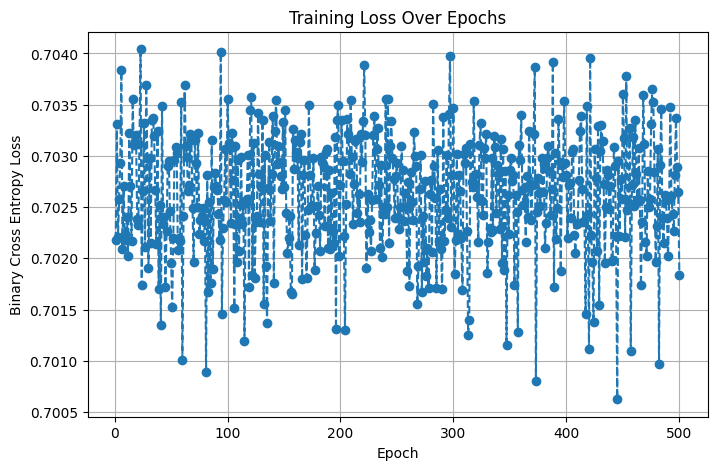

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, linestyle='--', marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

In [18]:
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train)
    y_train_pred = (y_train_pred > 0.5).float()

# confusion matrix
confusion_matrix(y_train, y_train_pred)

array([[81, 43],
       [34, 79]])

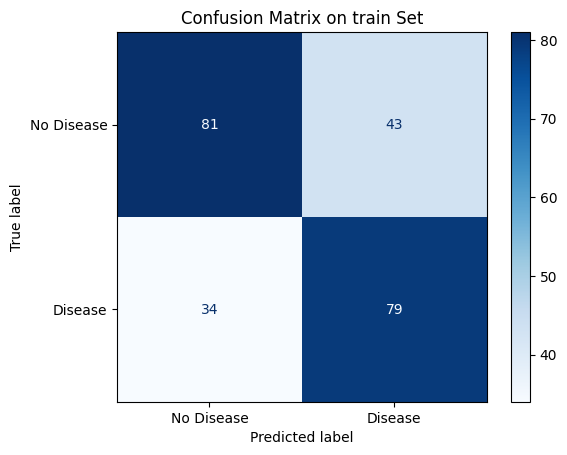

In [19]:
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on train Set")
plt.grid(False)
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

# Put model in evaluation mode
model.eval()

# Turn off gradient tracking
with torch.no_grad():
    y_train_logits = model(X_train)
    y_train_probs = torch.sigmoid(y_train_logits)
    y_train_preds = (y_train_probs >= 0.5).float()  # threshold at 0.5

    # Compute test loss
    train_loss = loss_fn(y_train_logits, y_train)

# Accuracy
train_acc = accuracy_score(y_train.numpy(), y_train_preds.numpy())

print(f"Train Loss: {train_loss.item():.4f}")
print(f"Train Accuracy: {train_acc * 100:.2f}%")

Train Loss: 0.6603
Train Accuracy: 47.68%


In [23]:


# Put model in evaluation mode
model.eval()

# Turn off gradient tracking
with torch.no_grad():
    y_train_logits = model(X_train)
    y_train_probs = torch.sigmoid(y_train_logits)
    y_train_preds = (y_train_probs >= 0.5).float()  # threshold at 0.5

    # Compute test loss
    train_loss = loss_fn(y_train_logits, y_train)

# Accuracy
train_acc = accuracy_score(y_train.numpy(), y_train_preds.numpy())

print(f"Train Loss: {train_loss.item():.4f}")
print(f"Train Accuracy: {train_acc * 100:.2f}%")

Train Loss: 0.6603
Train Accuracy: 47.68%


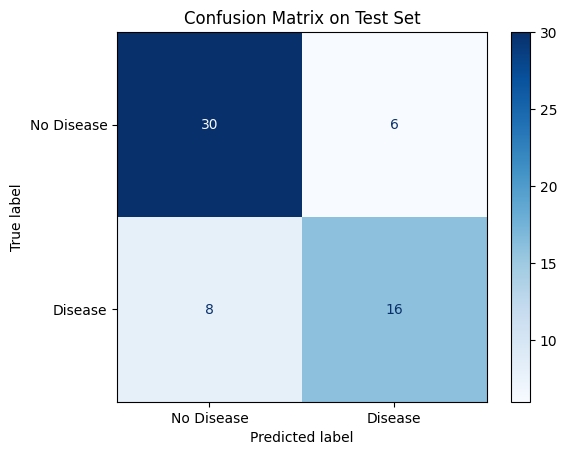

In [25]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    y_test_pred = (y_test_pred > 0.5).float()

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.grid(False)
plt.show()

In [26]:
import joblib


torch.save(custom_model.state_dict(), 'custom_model_weights.pth')

joblib.dump(scaler, 'feature_scaler.pkl')

['feature_scaler.pkl']

In [27]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target'],
      dtype='object')